# Model interpretability with SHAP

In [1]:
# Libraries
import joblib
import shap
import pandas as pd

from will_you_buy_an_ev.config.paths import MODELS_PATH, RAW_DATA_PATH, FIGURES_PATH    
from will_you_buy_an_ev.data.feature_engineer import create_features
import matplotlib.pyplot as plt

/Users/coreymichaud/Desktop/Code/will-you-buy-an-ev/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load model
pipe = joblib.load(MODELS_PATH / "lgbmc.joblib")

In [3]:
# Load data
train = pd.read_csv(RAW_DATA_PATH / "train.csv")

# Drop unused 'id' column
train = train.drop(columns=["id"])

# Create X/y split
X = train.drop(columns=["Will_Buy_EV"])
y = train["Will_Buy_EV"].map({"No": 0, "Yes": 1})

# Feature engineering
X = create_features(X)

/Users/coreymichaud/Desktop/Code/will-you-buy-an-ev/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


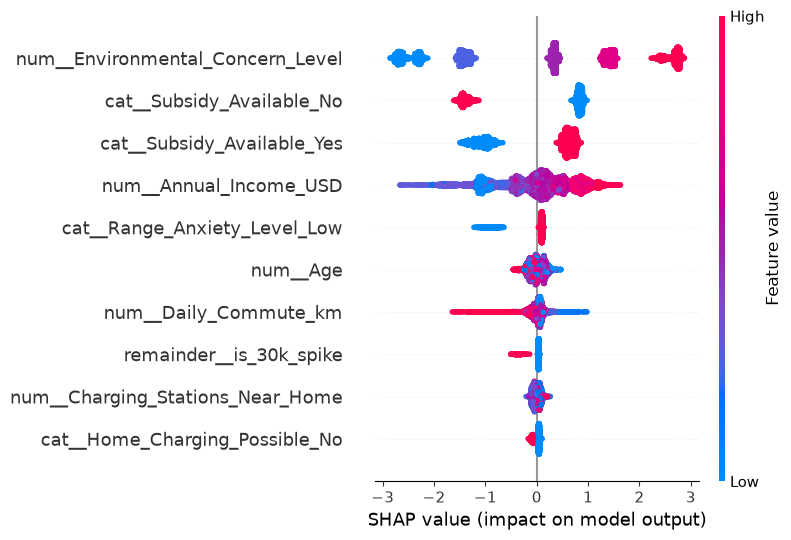

In [4]:
# SHAP feature importance

# Transform the data using the fitted preprocessor
X_transformed = pipe.named_steps["preprocessor"].transform(X)
X_sample = shap.sample(X_transformed, 10000)

# Get the fitted LightGBM model
model = pipe.named_steps["classifier"]

# Get transformed feature names
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()

# SHAP explainer
explainer = shap.TreeExplainer(model)

if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# SHAP summary plot
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=10)

# Save plot
plt.savefig(FIGURES_PATH / "shap_summary.png", bbox_inches="tight", dpi=150)
plt.close()